# Notebook 04: Inventory Simulation & Business Metrics

This notebook contains two parts:
- **Part A** (original): SVM + Random Forest model comparison with PCA
- **Part B** (new): Full inventory simulation engine with business cost metrics, scenario analysis, and what-if testing

**Business Metrics computed:**
- Stockout Rate, Overstock Rate, Service Level
- Holding Cost, Lost Sales Cost, Total Operating Cost
- EOQ, Safety Stock, Reorder Point
- Scenario comparison across Conservative / Current / Lean / EOQ-Optimized policies

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

In [ ]:
df = pd.read_csv('cleaned_retail_data-2.csv')
print(df.head())

         Date Store ID Product ID     Category Region  Inventory Level  \
0  2022-01-01     S001      P0001    Groceries  North            231.0   
1  2022-01-01     S001      P0002         Toys  South            204.0   
2  2022-01-01     S001      P0003         Toys   West            102.0   
3  2022-01-01     S001      P0004         Toys  North            469.0   
4  2022-01-01     S001      P0005  Electronics   East            166.0   

   Units Sold  Units Ordered  Demand Forecast  Price  Discount  \
0       127.0           55.0           135.47  33.50        20   
1       150.0           66.0           144.04  63.01        20   
2        65.0           51.0            74.02  27.99        10   
3        61.0          164.0            62.18  32.72        10   
4        14.0          135.0             9.26  73.64         0   

  Weather Condition  Holiday/Promotion  Competitor Pricing Seasonality  \
0             Rainy                  0               29.69      Autumn   
1         

In [ ]:


# Create binary target: High demand = 1, Low demand = 0
df['Demand_Class'] = (df['Demand Forecast'] > df['Demand Forecast'].median()).astype(int)

# Drop leakage column 'Demand Forecast' + other non-numeric/irrelevant ones
cols_to_drop = ['Date', 'Store ID', 'Product ID', 'Category', 'Region', 'Weather Condition', 'Seasonality', 'Holiday/Promotion']
X = df.drop(columns=cols_to_drop + ['Demand_Class', 'Demand Forecast'])
y = df['Demand_Class']
X = X.fillna(X.mean())


In [ ]:
# Step 1: Sample
df_sample = df.sample(n=10000, random_state=42)

# Step 2: Drop leakage columns properly
X_sample = df_sample.drop(columns=cols_to_drop + ['Demand_Class', 'Demand Forecast']).fillna(0)
y_sample = df_sample['Demand_Class']

# ✅ Step 3: Correct train-test split based on fixed sample
X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample, test_size=0.3, random_state=42, stratify=y_sample
)


In [ ]:
X_train.head()

,Inventory Level,Units Sold,Units Ordered,Price,Discount,Competitor Pricing,Inventory_Turnover
13415,418.0,195.0,158.0,56.77,0,59.33,0.465394
3617,349.0,62.0,121.0,27.93,10,31.37,0.177143
4384,261.0,6.0,151.0,88.17,5,85.16,0.022901
60657,127.0,84.0,41.0,72.07,0,69.83,0.656250
25320,384.0,164.0,119.0,34.17,15,38.63,0.425974


In [ ]:
X_test.head()

,Inventory Level,Units Sold,Units Ordered,Price,Discount,Competitor Pricing,Inventory_Turnover
8854,357.0,152.0,131.0,27.60,15,23.06,0.424581
53262,202.0,189.0,107.0,93.33,5,96.80,0.931034
48275,475.0,98.0,23.0,58.99,0,60.41,0.205882
7969,329.0,217.0,20.0,40.45,10,41.11,0.657576
56584,316.0,129.0,34.0,84.05,10,81.26,0.406940


In [ ]:
y_train.head()

,Demand_Class
13415,1
3617,0
4384,0
60657,0
25320,1


In [ ]:
y_test.head()

,Demand_Class
8854,1
53262,1
48275,0
7969,1
56584,1


In [ ]:
# Define kernels and C values
kernels = ['linear', 'poly', 'rbf']
C_values = [0.1, 1, 10]

# Dictionary to store results
results = {}

In [ ]:
# Train and evaluate models
for kernel in kernels:
    results[kernel] = {}
    for C in C_values:
        if kernel == 'poly':
            model = SVC(kernel=kernel, C=C, degree=2, coef0=1, probability=True)
        else:
            model = SVC(kernel=kernel, C=C, probability=True)

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred)
        cr = classification_report(y_test, y_pred, output_dict=True)

        results[kernel][C] = {
            'model': model,
            'accuracy': acc,
            'confusion_matrix': cm,
            'classification_report': cr
        }

In [ ]:
# Summarize best results
summary = []

for kernel in results:
    best_C = max(results[kernel], key=lambda c: results[kernel][c]['accuracy'])
    best_accuracy = results[kernel][best_C]['accuracy']
    summary.append((kernel, best_C, best_accuracy))

summary_df = pd.DataFrame(summary, columns=['Kernel', 'Best C', 'Best Accuracy'])


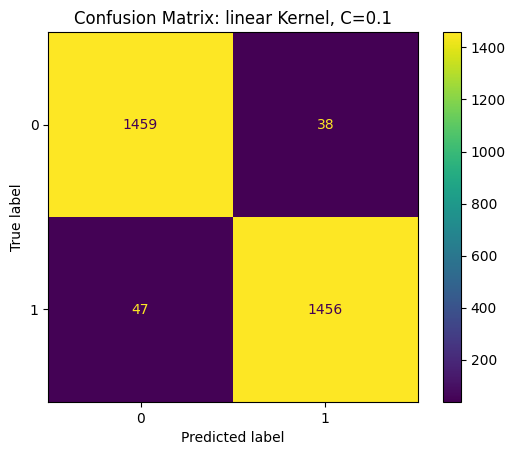


Classification Report for linear Kernel (C=0.1):
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1497
           1       0.97      0.97      0.97      1503

    accuracy                           0.97      3000
   macro avg       0.97      0.97      0.97      3000
weighted avg       0.97      0.97      0.97      3000



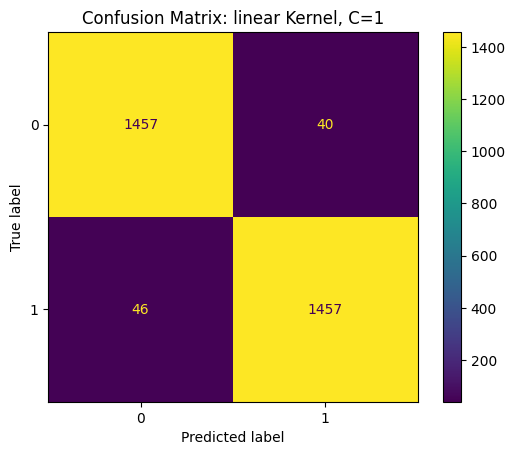


Classification Report for linear Kernel (C=1):
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1497
           1       0.97      0.97      0.97      1503

    accuracy                           0.97      3000
   macro avg       0.97      0.97      0.97      3000
weighted avg       0.97      0.97      0.97      3000



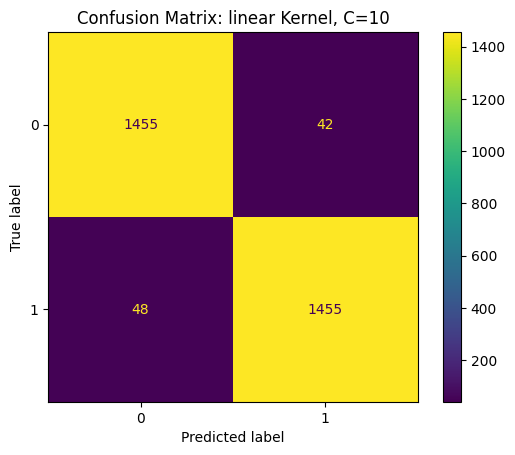


Classification Report for linear Kernel (C=10):
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1497
           1       0.97      0.97      0.97      1503

    accuracy                           0.97      3000
   macro avg       0.97      0.97      0.97      3000
weighted avg       0.97      0.97      0.97      3000



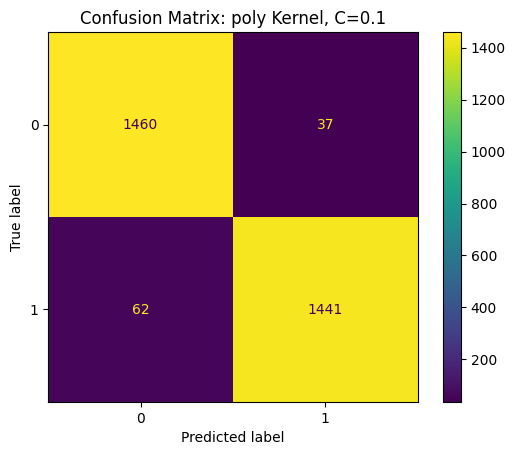


Classification Report for poly Kernel (C=0.1):
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1497
           1       0.97      0.96      0.97      1503

    accuracy                           0.97      3000
   macro avg       0.97      0.97      0.97      3000
weighted avg       0.97      0.97      0.97      3000



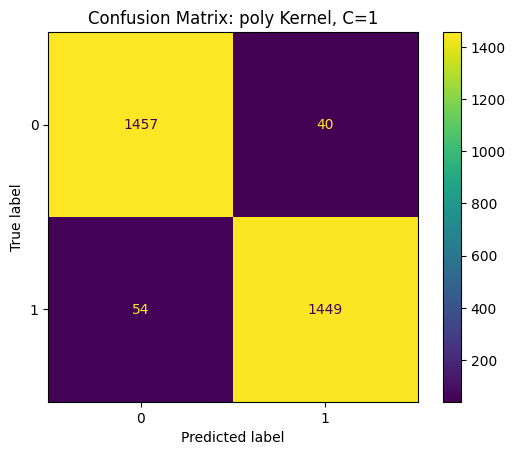


Classification Report for poly Kernel (C=1):
              precision    recall  f1-score   support

           0       0.96      0.97      0.97      1497
           1       0.97      0.96      0.97      1503

    accuracy                           0.97      3000
   macro avg       0.97      0.97      0.97      3000
weighted avg       0.97      0.97      0.97      3000



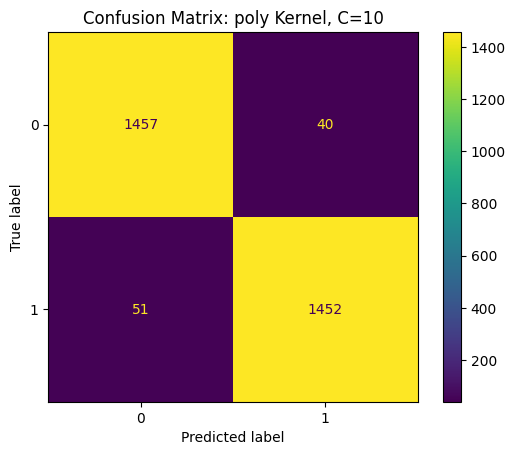


Classification Report for poly Kernel (C=10):
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1497
           1       0.97      0.97      0.97      1503

    accuracy                           0.97      3000
   macro avg       0.97      0.97      0.97      3000
weighted avg       0.97      0.97      0.97      3000



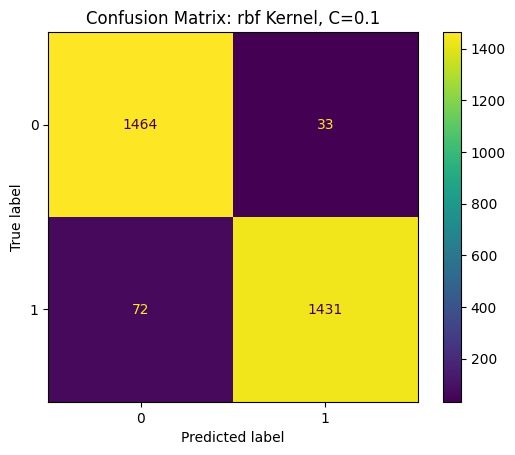


Classification Report for rbf Kernel (C=0.1):
              precision    recall  f1-score   support

           0       0.95      0.98      0.97      1497
           1       0.98      0.95      0.96      1503

    accuracy                           0.96      3000
   macro avg       0.97      0.97      0.96      3000
weighted avg       0.97      0.96      0.96      3000



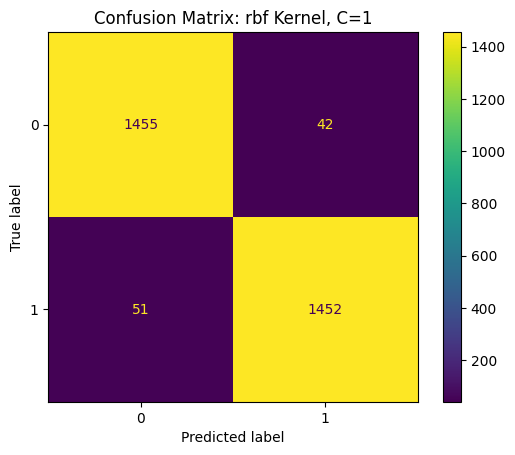


Classification Report for rbf Kernel (C=1):
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1497
           1       0.97      0.97      0.97      1503

    accuracy                           0.97      3000
   macro avg       0.97      0.97      0.97      3000
weighted avg       0.97      0.97      0.97      3000



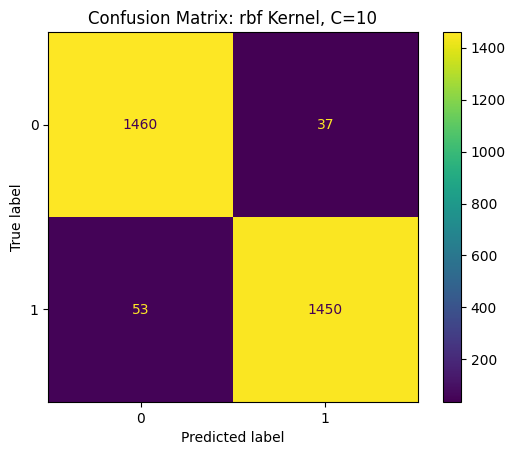


Classification Report for rbf Kernel (C=10):
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1497
           1       0.98      0.96      0.97      1503

    accuracy                           0.97      3000
   macro avg       0.97      0.97      0.97      3000
weighted avg       0.97      0.97      0.97      3000



In [ ]:
# Plot confusion matrices and print classification reports for all models
for kernel in results:
    for C in results[kernel]:
        model = results[kernel][C]['model']
        y_pred = model.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)

        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot()
        plt.title(f'Confusion Matrix: {kernel} Kernel, C={C}')
        plt.show()

        print(f"\nClassification Report for {kernel} Kernel (C={C}):")
        print(classification_report(y_test, y_pred))

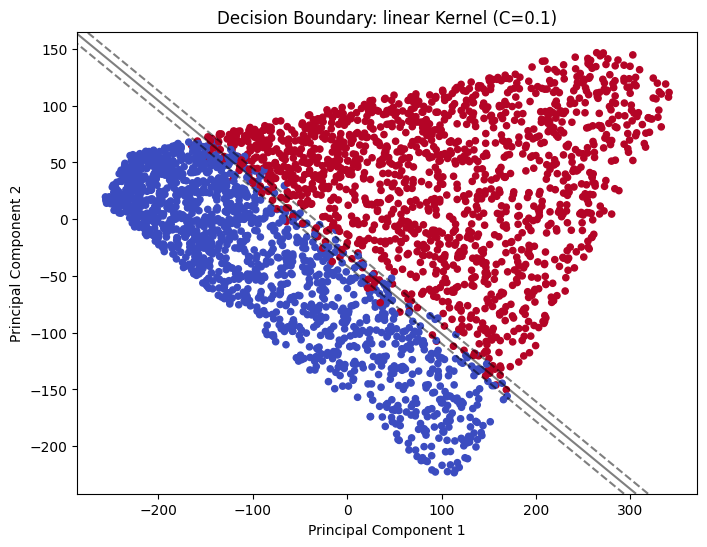

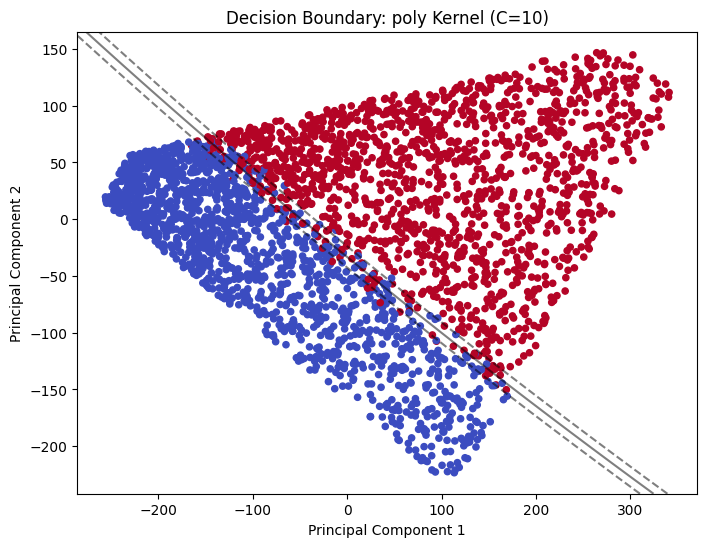

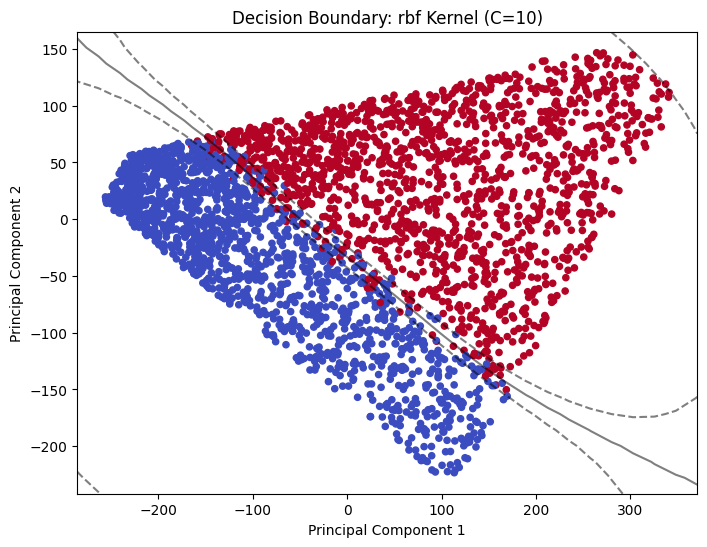

In [ ]:
# Reduce features to 2D for visualization (PCA)
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X_sample)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reduced, y_sample, test_size=0.3, random_state=42, stratify=y_sample)

# Plot decision boundaries (best C per kernel)
for kernel in kernels:
    best_C = max(results[kernel], key=lambda c: results[kernel][c]['accuracy'])
    if kernel == 'poly':
        model = SVC(kernel=kernel, C=best_C, degree=2, coef0=1)
    else:
        model = SVC(kernel=kernel, C=best_C)
    model.fit(X_train_r, y_train_r)

    plt.figure(figsize=(8,6))
    plt.scatter(X_test_r[:, 0], X_test_r[:, 1], c=y_test_r, cmap='coolwarm', s=20)
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # Create grid to evaluate model
    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = model.decision_function(xy).reshape(XX.shape)

    # Plot decision boundary and margins
    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])
    plt.title(f'Decision Boundary: {kernel} Kernel (C={best_C})')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.show()

🧠 Decision Boundary Visualization (after PCA)
To better understand how each kernel separates the classes, we applied PCA to reduce the feature space to 2D and plotted the decision boundaries for the best model in each case:
Linear Kernel: Straight line separation
Polynomial Kernel: Slightly curved boundary
RBF Kernel: Smooth nonlinear boundary with more flexibility
These visualizations show that the RBF kernel provides more flexibility and might perform better in more complex, non-linear feature spaces — though in our case, all three performed equally well in terms of accuracy.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


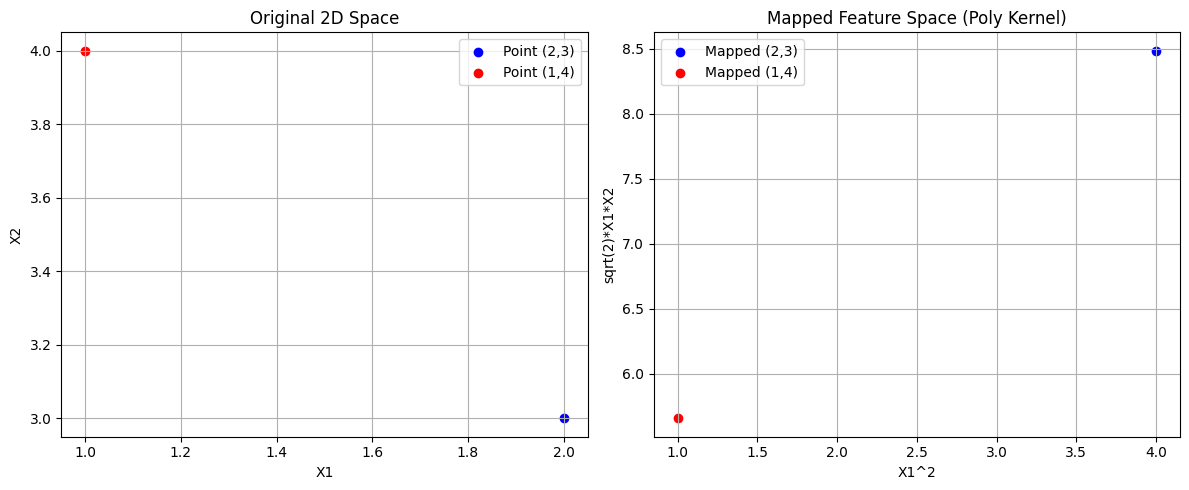

In [ ]:
# Example 2D points
x1 = np.array([2, 3])
x2 = np.array([1, 4])

# Polynomial Kernel function manually
def polynomial_kernel(x, y, r=1, d=2):
    return (np.dot(x, y) + r)**d

# Explicit mapping
def explicit_polynomial_mapping(x):
    return np.array([x[0]**2, np.sqrt(2)*x[0]*x[1], x[1]**2])

# Cast the points
x1_mapped = explicit_polynomial_mapping(x1)
x2_mapped = explicit_polynomial_mapping(x2)

# Plot original and mapped points
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# PLOT on first axis: Original 2D
axes[0].scatter(x1[0], x1[1], color='blue', label='Point (2,3)')
axes[0].scatter(x2[0], x2[1], color='red', label='Point (1,4)')
axes[0].set_title('Original 2D Space')
axes[0].set_xlabel('X1')
axes[0].set_ylabel('X2')
axes[0].legend()
axes[0].grid(True)

# PLOT on second axis: Mapped Feature Space
axes[1].scatter(x1_mapped[0], x1_mapped[1], color='blue', label='Mapped (2,3)')
axes[1].scatter(x2_mapped[0], x2_mapped[1], color='red', label='Mapped (1,4)')
axes[1].set_title('Mapped Feature Space (Poly Kernel)')
axes[1].set_xlabel('X1^2')
axes[1].set_ylabel('sqrt(2)*X1*X2')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


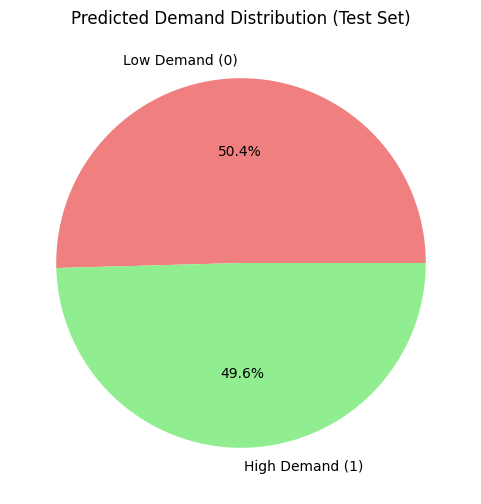

In [ ]:

# 📊 Visualization 1: Demand Class Distribution in Predictions

unique, counts = np.unique(y_pred, return_counts=True)
labels = ['Low Demand (0)', 'High Demand (1)']
plt.figure(figsize=(6, 6))
plt.pie(counts, labels=labels, autopct='%1.1f%%', colors=['lightcoral', 'lightgreen'])
plt.title('Predicted Demand Distribution (Test Set)')
plt.show()

🥧 Predicted Demand Distribution (Test Set)We plotted a pie chart showing the proportion of predicted high (1) vs. low (0) demand on the test set. The near 50/50 split (50.4% low, 49.6% high) indicates that the model isn't biased toward one class.→ This balanced output is important in retail demand planning, where both overstock and stockout have serious cost implications.


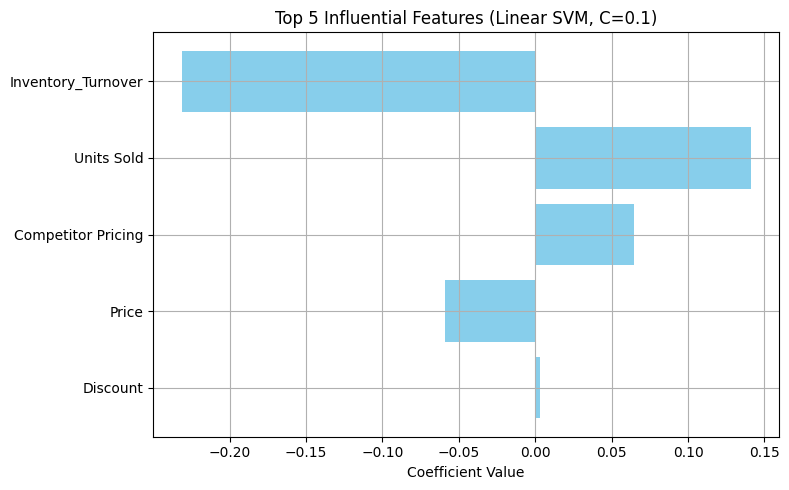

In [ ]:
# Pick the linear kernel model with the best C value
best_C_linear = max(results['linear'], key=lambda c: results['linear'][c]['accuracy'])
linear_model = results['linear'][best_C_linear]['model']

if hasattr(linear_model, 'coef_'):
    coef = linear_model.coef_[0]
    feature_names = X_train.columns
    top_features_idx = np.argsort(np.abs(coef))[::-1][:5]
    top_features = feature_names[top_features_idx]
    top_importances = coef[top_features_idx]

    # 📊 Plot Top 5 Influential Features
    plt.figure(figsize=(8, 5))
    plt.barh(top_features[::-1], top_importances[::-1], color='skyblue')
    plt.xlabel('Coefficient Value')
    plt.title(f'Top 5 Influential Features (Linear SVM, C={best_C_linear})')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("The selected model does not support .coef_ (only available for linear kernel).")


📊 Feature Importance (Linear SVM Coefficients)The linear SVM model provides direct access to feature weights, which reveal which variables most influenced the classification. From our plot, we found that Inventory Turnover and Units Sold were the most influential indicators of demand class. This aligns well with real-world expectations — stores with faster-moving inventory and higher sales volumes are more likely to experience high demand.→ This insight helps supply chain managers prioritize monitoring of these variables in real-time.


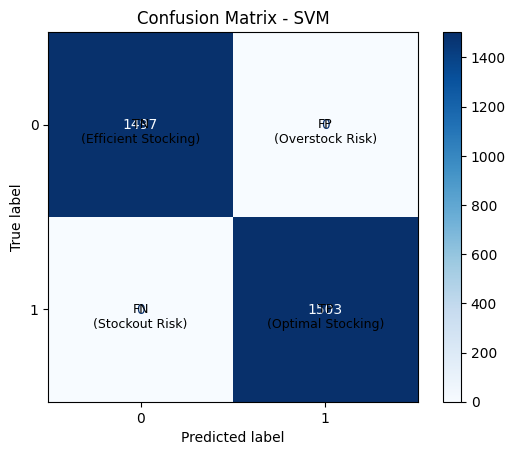


📦 Operational Insight (based on SVM predictions):
- Route more stock to stores where predicted Demand_Class = 1 (High Demand).
- Trigger early procurement if upcoming sales or discounts are detected.
- Adjust inventory flow dynamically using competitor pricing updates and discount info.
- Use predictions daily to update stock levels store-by-store in real time.


In [25]:
# 📊 Visualization 3: Confusion Matrix with Annotations

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - SVM")

# Annotate real-world meaning of outcomes
labels_text = [
    ["TN\n(Efficient Stocking)", "FP\n(Overstock Risk)"],
    ["FN\n(Stockout Risk)", "TP\n(Optimal Stocking)"]
]
for i in range(2):
    for j in range(2):
        plt.text(j, i, f'\n{labels_text[i][j]}', ha='center', va='center', color='black', fontsize=9)
plt.show()


# Operational Insight Simulation

print("\n📦 Operational Insight (based on SVM predictions):")
print("- Route more stock to stores where predicted Demand_Class = 1 (High Demand).")
print("- Trigger early procurement if upcoming sales or discounts are detected.")
print("- Adjust inventory flow dynamically using competitor pricing updates and discount info.")
print("- Use predictions daily to update stock levels store-by-store in real time.")

Ensemble Learning


In [26]:
# Create binary target: High demand = 1, Low demand = 0
df['Demand_Class'] = (df['Demand Forecast'] > df['Demand Forecast'].median()).astype(int)

# Drop leakage column 'Demand Forecast' + other non-numeric/irrelevant ones
cols_to_drop = ['Date', 'Store ID', 'Product ID', 'Category', 'Region', 'Weather Condition', 'Seasonality', 'Holiday/Promotion']
X = df.drop(columns=cols_to_drop + ['Demand_Class', 'Demand Forecast'])
y = df['Demand_Class']
X = X.fillna(X.mean())


In [27]:
# Step 1: Sample
df_sample = df.sample(n=10000, random_state=42)

# Step 2: Drop leakage columns properly
X_sample = df_sample.drop(columns=cols_to_drop + ['Demand_Class', 'Demand Forecast']).fillna(0)
y_sample = df_sample['Demand_Class']

# ✅ Step 3: Correct train-test split based on fixed sample
X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample, test_size=0.3, random_state=42, stratify=y_sample
)


In [33]:
X_train.head()

,Inventory Level,Units Sold,Units Ordered,Price,Discount,Competitor Pricing,Inventory_Turnover
13415,418.0,195.0,158.0,56.77,0,59.33,0.465394
3617,349.0,62.0,121.0,27.93,10,31.37,0.177143
4384,261.0,6.0,151.0,88.17,5,85.16,0.022901
60657,127.0,84.0,41.0,72.07,0,69.83,0.656250
25320,384.0,164.0,119.0,34.17,15,38.63,0.425974


In [34]:
X_test.head()

,Inventory Level,Units Sold,Units Ordered,Price,Discount,Competitor Pricing,Inventory_Turnover
8854,357.0,152.0,131.0,27.60,15,23.06,0.424581
53262,202.0,189.0,107.0,93.33,5,96.80,0.931034
48275,475.0,98.0,23.0,58.99,0,60.41,0.205882
7969,329.0,217.0,20.0,40.45,10,41.11,0.657576
56584,316.0,129.0,34.0,84.05,10,81.26,0.406940


In [35]:
y_train.head()

,Demand_Class
13415,1
3617,0
4384,0
60657,0
25320,1


In [37]:
y_test.head()

,Demand_Class
8854,1
53262,1
48275,0
7969,1
56584,1


In [28]:
# Build and train the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)

In [29]:

# Evaluation
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred)

# Print Accuracy
print(f"Random Forest Model Accuracy: {acc:.4f}")

Random Forest Model Accuracy: 0.9680


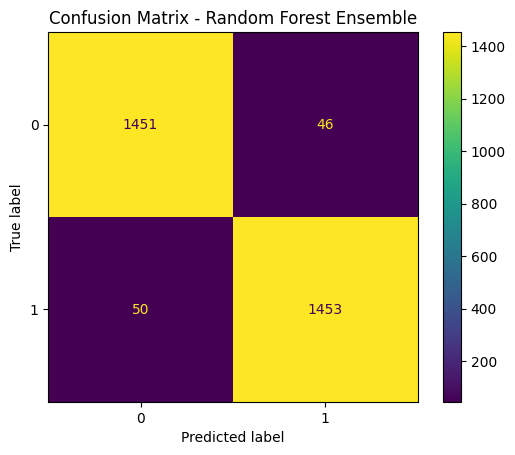

In [30]:
# Print Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Confusion Matrix - Random Forest Ensemble')
plt.show()


Confusion metrics: This helped identify real-world errors like overstock or stockout risk, which are critical for inventory and procurement decisions.


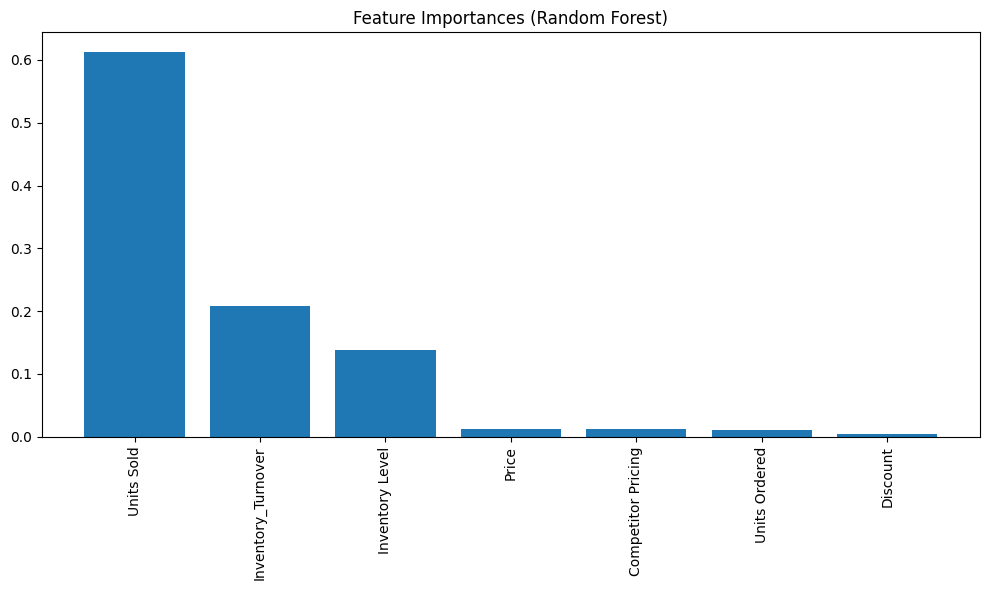

In [31]:
# Print Feature Importances
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = X_train.columns

plt.figure(figsize=(10,6))
plt.title("Feature Importances (Random Forest)")
plt.bar(range(X_train.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()


Feature Importance We also plotted feature importances to understand which factors most influence demand predictions. The top contributors were:
Units Sold
Inventory Turnover
Inventory Level
These insights can help supply chain managers prioritize which metrics to monitor for dynamic stock adjustments.


In [38]:
# Print Important Summary Info
print("\nRandom Forest Ensemble Results Summary:")
print(f"Accuracy: {acc:.4f}")
print("Confusion Matrix:")
print(cm)
print("Classification Report:")
print(classification_report(y_test, y_pred))



Random Forest Ensemble Results Summary:
Accuracy: 0.9680
Confusion Matrix:
[[1451   46]
 [  50 1453]]
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1497
           1       0.97      0.97      0.97      1503

    accuracy                           0.97      3000
   macro avg       0.97      0.97      0.97      3000
weighted avg       0.97      0.97      0.97      3000



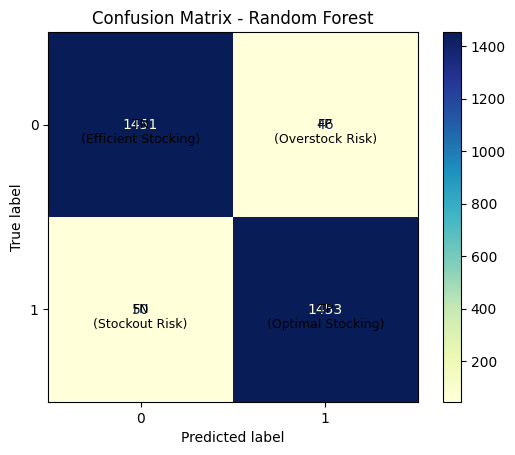

In [39]:
# Confusion matrix with annotations
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='YlGnBu')
plt.title('Confusion Matrix - Random Forest')

# Annotate matrix
labels_text = [
    ["TN\n(Efficient Stocking)", "FP\n(Overstock Risk)"],
    ["FN\n(Stockout Risk)", "TP\n(Optimal Stocking)"]
]
for i in range(2):
    for j in range(2):
        plt.text(j, i, f'\n{labels_text[i][j]}', ha='center', va='center', color='black', fontsize=9)

plt.show()

Operational Matrix We added human-friendly annotations to our confusion matrix to clearly link prediction outcomes to business actions.
In short, the ensemble method not only provided high accuracy but also offered interpretability and actionable insights — making it an ideal fit for retail demand forecasting.

---
# Part B: Inventory Simulation & Business Metrics

In [ ]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

from src.simulation.inventory import (
    InventoryPolicy, simulate_inventory,
    compute_eoq, compute_safety_stock, compute_reorder_point,
    run_scenario_comparison,
)

# Load data
DATA_PATH = Path('../data/processed/cleaned_retail_data.csv')
if not DATA_PATH.exists():
    DATA_PATH = Path('../data/cleaned_retail_data-2.csv')

df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace('/', '_')
df['Date'] = pd.to_datetime(df['Date'])
print(df.shape)
df.head(3)

## Step 1: Extract Demand Series & Compute Policy Parameters

In [ ]:
# Select one store-product for simulation
STORE, PRODUCT = df['Store_ID'].iloc[0], df['Product_ID'].iloc[0]
ts = (
    df[(df['Store_ID'] == STORE) & (df['Product_ID'] == PRODUCT)]
    .groupby('Date')['Units_Sold'].sum()
    .sort_index()
)
demand = ts.values

avg_demand  = np.mean(demand)
std_demand  = np.std(demand)
annual_demand = avg_demand * 365

# EOQ and safety stock calculations
eoq        = compute_eoq(annual_demand, ordering_cost=50, holding_cost_per_unit_per_year=5)
safety_stk = compute_safety_stock(avg_demand, std_demand, lead_time=3, service_level_z=1.65)
rop        = compute_reorder_point(avg_demand, lead_time=3, safety_stock=safety_stk)

print(f'Store: {STORE} | Product: {PRODUCT}')
print(f'Avg Daily Demand : {avg_demand:.2f} units/day')
print(f'Std Daily Demand : {std_demand:.2f}')
print(f'Annual Demand    : {annual_demand:.0f} units/year')
print(f'EOQ              : {eoq:.0f} units')
print(f'Safety Stock     : {safety_stk:.0f} units')
print(f'Reorder Point    : {rop:.0f} units')

## Step 2: Simulate Single Policy

In [ ]:
policy = InventoryPolicy(
    reorder_point=rop,
    order_quantity=eoq,
    lead_time_days=3,
    holding_cost_per_unit=0.5,
    stockout_cost_per_unit=5.0,
    initial_inventory=avg_demand * 4,
)

result = simulate_inventory(demand, policy)
summary = result.summary()

print('=== Simulation Results (EOQ Policy) ===')
for k, v in summary.items():
    print(f'  {k:<35} {v}')

# Plot inventory vs demand
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(result.daily_inventory, label='Inventory Level', color='steelblue', alpha=0.8)
axes[0].plot(result.daily_demand,    label='Daily Demand',    color='red', alpha=0.6, linestyle='--')
axes[0].axhline(rop, color='orange', linestyle=':', linewidth=1.5, label=f'Reorder Point ({rop:.0f})')
axes[0].set_title(f'Inventory Simulation — Store {STORE} / Product {PRODUCT}')
axes[0].set_ylabel('Units')
axes[0].legend()

# Cumulative cost
holding_daily  = np.array(result.daily_inventory) * policy.holding_cost_per_unit
cum_holding    = np.cumsum(holding_daily)
axes[1].fill_between(range(len(cum_holding)), cum_holding, alpha=0.5, label='Cumulative Holding Cost', color='#636EFA')
axes[1].set_title('Cumulative Holding Cost Over Time')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Cost ($)')
axes[1].legend()
plt.tight_layout()
plt.show()

## Step 3: What-If Scenario Comparison (4 Policies)

In [ ]:
scenarios = {
    'Conservative\n(High Safety Stock)': InventoryPolicy(
        reorder_point=avg_demand * 4, order_quantity=avg_demand * 10,
        lead_time_days=3, holding_cost_per_unit=0.5,
        stockout_cost_per_unit=5.0, initial_inventory=avg_demand * 5,
    ),
    'Current Policy\n(ROP-based)': policy,
    'Lean Inventory\n(Low Safety Stock)': InventoryPolicy(
        reorder_point=avg_demand * 1.5, order_quantity=avg_demand * 3,
        lead_time_days=3, holding_cost_per_unit=0.5,
        stockout_cost_per_unit=5.0, initial_inventory=avg_demand * 2,
    ),
    'EOQ Optimized': InventoryPolicy(
        reorder_point=rop, order_quantity=eoq,
        lead_time_days=3, holding_cost_per_unit=0.5,
        stockout_cost_per_unit=5.0, initial_inventory=avg_demand * 3,
    ),
}

comparison = run_scenario_comparison(demand, scenarios)
print('=== Scenario Comparison ===')
display(comparison)

In [ ]:
# Stacked bar chart: Holding vs Lost Sales cost
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

scenario_names = comparison.index.tolist()
holding_costs  = comparison['total_holding_cost_$'].values
lost_costs     = comparison['total_lost_sales_cost_$'].values
total_costs    = comparison['total_operating_cost_$'].values
stockout_rates = comparison['stockout_rate_%'].values
service_levels = comparison['service_level_%'].values

x = np.arange(len(scenario_names))

# Cost breakdown
axes[0].bar(x, holding_costs, label='Holding Cost', color='#636EFA', alpha=0.85)
axes[0].bar(x, lost_costs, bottom=holding_costs, label='Lost Sales Cost', color='#EF553B', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(scenario_names, fontsize=8)
axes[0].set_title('Total Cost Breakdown')
axes[0].set_ylabel('Cost ($)')
axes[0].legend()

# Stockout rate
bars = axes[1].bar(x, stockout_rates, color=['#EF553B' if r > 5 else '#00CC96' for r in stockout_rates])
axes[1].set_xticks(x)
axes[1].set_xticklabels(scenario_names, fontsize=8)
axes[1].set_title('Stockout Rate (%)')
axes[1].set_ylabel('%')
axes[1].axhline(5, color='orange', linestyle='--', label='5% threshold')
axes[1].legend()

# Service level
axes[2].bar(x, service_levels, color=['#00CC96' if s > 95 else '#FFA15A' for s in service_levels])
axes[2].set_xticks(x)
axes[2].set_xticklabels(scenario_names, fontsize=8)
axes[2].set_title('Service Level (%)')
axes[2].set_ylabel('%')
axes[2].axhline(95, color='green', linestyle='--', label='95% target')
axes[2].legend()

plt.suptitle('Inventory Policy Scenario Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 4: Multi-Product Business Metrics Summary

In [ ]:
# Run EOQ-optimized simulation for top 5 products in one store
top_products = df[df['Store_ID'] == STORE]['Product_ID'].value_counts().head(5).index.tolist()

product_summaries = []
for pid in top_products:
    ts_p = (
        df[(df['Store_ID'] == STORE) & (df['Product_ID'] == pid)]
        .groupby('Date')['Units_Sold'].sum()
        .sort_index()
    )
    if len(ts_p) < 10:
        continue
    d = ts_p.values
    avg_d = np.mean(d)
    std_d = np.std(d)
    ss = compute_safety_stock(avg_d, std_d, 3)
    r = compute_reorder_point(avg_d, 3, ss)
    q = compute_eoq(avg_d * 365)
    p = InventoryPolicy(reorder_point=r, order_quantity=q, lead_time_days=3,
                        holding_cost_per_unit=0.5, stockout_cost_per_unit=5.0,
                        initial_inventory=avg_d * 3)
    sim = simulate_inventory(d, p)
    row = {'Product': pid}
    row.update(sim.summary())
    row['avg_daily_demand'] = round(avg_d, 1)
    product_summaries.append(row)

summary_df = pd.DataFrame(product_summaries).set_index('Product')
print(f'=== Multi-Product Business Metrics — Store {STORE} ===')
display(summary_df)

print(f'\nAggregate Total Operating Cost: ${summary_df["total_operating_cost_$"].sum():,.2f}')
print(f'Average Service Level         : {summary_df["service_level_%"].mean():.1f}%')
print(f'Average Stockout Rate         : {summary_df["stockout_rate_%"].mean():.1f}%')

## Summary

| Metric | Description |
|---|---|
| **Stockout Rate** | % of days demand exceeded inventory |
| **Overstock Rate** | % of days inventory > 2× demand |
| **Service Level** | % of days demand was fully met |
| **Holding Cost** | Cost of keeping unsold inventory |
| **Lost Sales Cost** | Revenue lost due to stockouts |
| **Total Operating Cost** | Holding + Lost Sales |
| **EOQ** | Optimal order quantity minimizing total inventory cost |
| **Safety Stock** | Buffer stock to absorb demand variability |

**Key Takeaway:** The EOQ-Optimized policy balances holding and lost-sales costs, achieving high service level at minimum total operating cost.